In [1]:
#Library Imports
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random
import time
import matplotlib.pyplot as plt

In [2]:
class DroneRescueEnv(gym.Env):
    def __init__(self):
        super(DroneRescueEnv, self).__init__()
        
        # Grid size
        self.grid_size = 6
        self.max_battery = 10
        self.max_steps = 75
        self.wind_prob = 0.3 # 30% chance of wind affecting movement
        # Define action space: Up, Down, Left, Right, Hover
        self.action_space = spaces.Discrete(5)
        
        # Observation space: (row, col, battery, rescued_targets_status)
        self.observation_space = spaces.Tuple((
            spaces.Discrete(self.grid_size),          # row position
            spaces.Discrete(self.grid_size),          # column position
            spaces.Discrete(self.max_battery+1),      # battery level
            spaces.MultiBinary(3)                     # rescue status (3 targets)
        ))

        

#   Symbol     Meaning 
#     S     Start position 
#     F     Free/Safe cell 
#     D     Dangerous zone 
#     R     Rescue target 
#     C     Charging station 
#     W     Wind zone 
#     X     Blocked cell / obstacle 
        # Grid configuration
        self.grid = np.array([
            ['S','F','F','D','F','F'],
            ['F','X','W','F','R','F'],
            ['F','F','D','F','F','W'],
            ['C','F','F','X','F','R'],
            ['F','F','D','F','W','F'],
            ['D','R','F','C','X','F']
        ])
        
        # Rescue target positions 
        self.rescue_targets = [(1,4), (3,5), (5,1)]
        self.start_pos = (0,0)
        self.initial_grid = self.grid.copy()
        self.reset()
    
    def reset(self):
        # Restore initial grid and reset drone to start
        self.grid = self.initial_grid.copy()
        self.pos = self.start_pos
        self.battery = self.max_battery
        self.rescued = [0,0,0]
        self.steps = 0 
        # Return initial state: (row, col, battery, rescued_status)
        return (self.pos[0], self.pos[1], self.battery, np.array(self.rescued))

    def get_valid_actions(self, state):
        # state = (row, col, battery, rescued_status)
        _, _, battery, rescued = state
        # No actions in terminal states
        if battery <= 0 or all(rescued):
            return []
        # 0=Up, 1=Down, 2=Left, 3=Right, 4=Hover
        return [0, 1, 2, 3, 4]

    def render(self):
        # Display grid; P marks current drone position
        for r in range(self.grid_size):
            row = []
            for c in range(self.grid_size):
                if (r, c) == self.pos:
                    row.append('P')
                else:
                    row.append(self.grid[r, c])
            print(' '.join(row))
        # Show current battery, rescued targets, and step count
        print(f"Battery: {self.battery} | Rescued: {self.rescued} | Steps: {self.steps}")
    
    #Action mapping: 0=Up, 1=Down, 2=Left, 3=Right, 4=Hover
    def step(self, action):
        r, c = self.pos
        # If current cell is wind zone, apply stochastic transition
        if self.grid[r,c] == 'W' and action in [0,1,2,3]:
            if random.random() < self.wind_prob:
                action = random.choice([0,1,2,3])  

        # Movement logic with boundary checks
        nr, nc = r, c
        if action == 0 and r > 0: nr -= 1                    # Up
        elif action == 1 and r < self.grid_size-1: nr += 1   # Down
        elif action == 2 and c > 0: nc -= 1                  # Left
        elif action == 3 and c < self.grid_size-1: nc += 1   # Right
        # Hover = stay
        
        # Check blocked cells
        if self.grid[nr,nc] == 'X':
            nr, nc = r, c  # stay in place
        
        self.pos = (nr,nc)
        self.battery -= 1
        self.steps += 1

        reward = -1  # move cost
        done = False
        entered_new_cell = (nr,nc) != (r,c)
        
        cell = self.grid[nr,nc]
        if cell == 'R':
            for idx, target in enumerate(self.rescue_targets):
                if (nr,nc) == target and self.rescued[idx] == 0:
                    reward += 20
                    self.rescued[idx] = 1
                    self.grid[nr,nc] = 'F'
                    break
        elif entered_new_cell and cell == 'C':
            reward += 5
            self.battery = self.max_battery
        elif entered_new_cell and cell == 'D':
            reward -= 10
        
        if self.battery <= 0:
            reward -= 20
            done = True
        if all(self.rescued):
            done = True
        if self.steps >= self.max_steps:
            print("Maximum steps crossed. Resetting environment.")
            done = True
        
        return (nr,nc,self.battery,np.array(self.rescued)), reward, done, {}


In [3]:
# Value Iteration parameters
THETA = 1e-3
GAMMA = 1.0  # undiscounted finite-horizon MDP
ACTIONS = [0, 1, 2, 3, 4]
ACTION_NAMES = {0: 'Up', 1: 'Down', 2: 'Left', 3: 'Right', 4: 'Hover'}


def normalize_state(state):
    r, c, b, rescued, steps = state
    return (r, c, b, tuple(int(x) for x in rescued), int(steps))


def is_terminal(state, max_steps):
    _, _, battery, rescued, steps = state
    return battery <= 0 or all(rescued) or steps >= max_steps


def get_cell_type(env, r, c, rescued):
    for idx, (tr, tc) in enumerate(env.rescue_targets):
        if (r, c) == (tr, tc):
            return 'R' if rescued[idx] == 0 else 'F'
    return env.initial_grid[r, c]


def apply_move(env, r, c, action):
    nr, nc = r, c
    if action == 0 and r > 0: nr -= 1
    elif action == 1 and r < env.grid_size - 1: nr += 1
    elif action == 2 and c > 0: nc -= 1
    elif action == 3 and c < env.grid_size - 1: nc += 1
    if env.initial_grid[nr, nc] == 'X':
        nr, nc = r, c
    return nr, nc


def get_action_probs(env, r, c, rescued, action):
    if get_cell_type(env, r, c, rescued) == 'W' and action in [0, 1, 2, 3]:
        probs = {a: env.wind_prob / 4 for a in [0, 1, 2, 3]}
        probs[action] += 1 - env.wind_prob
        return probs
    return {action: 1.0}


def get_transitions(env, state, action):
    r, c, battery, rescued, steps = state
    outcomes = {}
    for actual_action, prob in get_action_probs(env, r, c, rescued, action).items():
        nr, nc = apply_move(env, r, c, actual_action)
        new_battery = battery - 1
        new_rescued = list(rescued)
        new_steps = steps + 1
        reward = -1
        entered = (nr, nc) != (r, c)
        cell = get_cell_type(env, nr, nc, rescued)
        if cell == 'R':
            for idx, target in enumerate(env.rescue_targets):
                if (nr, nc) == target and new_rescued[idx] == 0:
                    reward += 20
                    new_rescued[idx] = 1
                    break
        elif entered and env.initial_grid[nr, nc] == 'C':
            reward += 5
            new_battery = env.max_battery
        elif entered and env.initial_grid[nr, nc] == 'D':
            reward -= 10
        done = new_battery <= 0 or all(new_rescued) or new_steps >= env.max_steps
        if new_battery <= 0:
            reward -= 20
        next_state = (nr, nc, new_battery, tuple(new_rescued), new_steps)
        key = (next_state, reward, done)
        outcomes[key] = outcomes.get(key, 0) + prob
    return [(p, ns, rw, dn) for (ns, rw, dn), p in outcomes.items()]


def enumerate_reachable_states(env, start_state):
    start_state = normalize_state(start_state)
    reachable = {start_state}
    queue = [start_state]
    while queue:
        state = queue.pop()
        if is_terminal(state, env.max_steps):
            continue
        for action in ACTIONS:
            for _, next_state, _, _ in get_transitions(env, state, action):
                if next_state not in reachable:
                    reachable.add(next_state)
                    queue.append(next_state)
    return reachable


def value_iteration(env, theta=THETA, gamma=GAMMA):
    start_state = normalize_state((0, 0, env.max_battery, (0, 0, 0), 0))
    states = list(enumerate_reachable_states(env, start_state))
    state_to_idx = {s: i for i, s in enumerate(states)}
    n = len(states)
    terminal = np.array([is_terminal(s, env.max_steps) for s in states])

    trans = [[[] for _ in range(5)] for _ in range(n)]
    for i, state in enumerate(states):
        if terminal[i]:
            for action in ACTIONS:
                trans[i][action] = [(1.0, i, 0.0, True)]
        else:
            for action in ACTIONS:
                trans[i][action] = [
                    (prob, state_to_idx[next_state], reward, done)
                    for prob, next_state, reward, done in get_transitions(env, state, action)
                ]

    V = np.zeros(n)
    iterations = 0
    final_delta = float('inf')
    non_terminal = np.where(~terminal)[0]

    start_time = time.time()
    while True:
        delta = 0.0
        for i in non_terminal:
            best_value = float('-inf')
            for action in ACTIONS:
                action_value = sum(
                    prob * (reward + (0.0 if done else gamma * V[j]))
                    for prob, j, reward, done in trans[i][action]
                )
                best_value = max(best_value, action_value)
            delta = max(delta, abs(best_value - V[i]))
            V[i] = best_value
        iterations += 1
        final_delta = delta
        if delta < theta:
            break

    V_dict = {states[i]: V[i] for i in range(n)}
    policy = {}
    for i, state in enumerate(states):
        if terminal[i]:
            continue
        best_action = 0
        best_value = float('-inf')
        for action in ACTIONS:
            action_value = sum(
                prob * (reward + (0.0 if done else gamma * V[j]))
                for prob, j, reward, done in trans[i][action]
            )
            if action_value > best_value:
                best_value = action_value
                best_action = action
        policy[state] = best_action

    runtime = time.time() - start_time
    return {
        'V': V_dict,
        'policy': policy,
        'states': set(states),
        'start_state': start_state,
        'reachable_state_count': n,
        'iterations': iterations,
        'final_delta': final_delta,
        'runtime_seconds': runtime,
    }


env = DroneRescueEnv()
results = value_iteration(env)

print("Value Iteration Results")
print("-" * 40)
print(f"Reachable states: {results['reachable_state_count']}")
print(f"Convergence iterations: {results['iterations']}")
print(f"Final delta (error): {results['final_delta']:.6f}")
print(f"Runtime (seconds): {results['runtime_seconds']:.4f}")
print("-" * 40)
print(f"V*({results['start_state']}) = {results['V'][results['start_state']]:.4f}")
print(f"pi*({results['start_state']}) = {ACTION_NAMES[results['policy'][results['start_state']]]}")

Value Iteration Results
----------------------------------------
Reachable states: 103763
Convergence iterations: 45
Final delta (error): 0.000000
Runtime (seconds): 16.3946
----------------------------------------
V*((0, 0, 10, (0, 0, 0), 0)) = 141.8787
pi*((0, 0, 10, (0, 0, 0), 0)) = Down


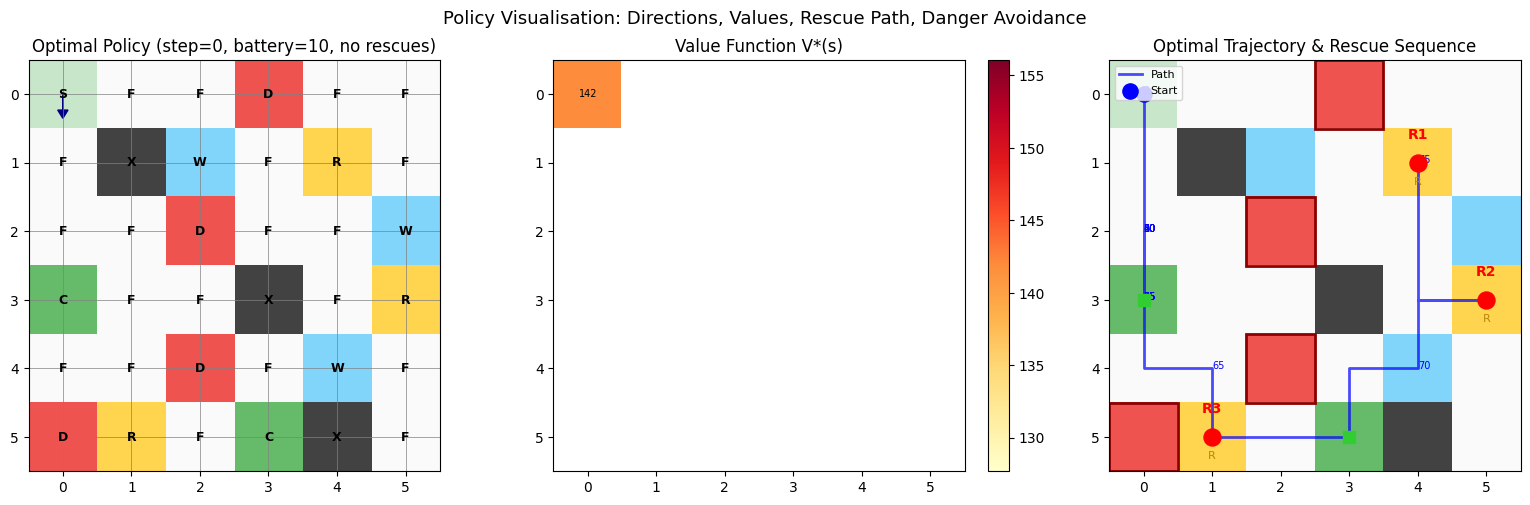

Rescue sequence (step -> target):
  3. step 66: rescue at (5, 1)
  2. step 72: rescue at (3, 5)
  1. step 75: rescue at (1, 4)


In [4]:
# Policy visualisation
CELL_COLORS = {
    'S': '#C8E6C9', 'F': '#FAFAFA', 'D': '#EF5350', 'R': '#FFD54F',
    'C': '#66BB6A', 'W': '#81D4FA', 'X': '#424242',
}
ARROW_OFFSETS = {0: (0, -0.35), 1: (0, 0.35), 2: (-0.35, 0), 3: (0.35, 0), 4: (0, 0)}


def deterministic_step(env, state, action):
    r, c, battery, rescued, steps = state
    nr, nc = apply_move(env, r, c, action)
    new_battery = battery - 1
    new_rescued = list(rescued)
    entered = (nr, nc) != (r, c)
    cell = get_cell_type(env, nr, nc, rescued)
    if cell == 'R':
        for idx, target in enumerate(env.rescue_targets):
            if (nr, nc) == target and new_rescued[idx] == 0:
                new_rescued[idx] = 1
                break
    elif entered and env.initial_grid[nr, nc] == 'C':
        new_battery = env.max_battery
    return normalize_state((nr, nc, new_battery, new_rescued, steps + 1))


def simulate_optimal_path(env, policy, max_steps=75):
    state = normalize_state((0, 0, env.max_battery, (0, 0, 0), 0))
    path = [state]
    rescue_sequence = []
    rescued_before = state[3]
    for _ in range(max_steps):
        if is_terminal(state, env.max_steps) or state not in policy:
            break
        state = deterministic_step(env, state, policy[state])
        path.append(state)
        for idx, target in enumerate(env.rescue_targets):
            if state[3][idx] == 1 and rescued_before[idx] == 0:
                rescue_sequence.append((len(path) - 1, target, idx + 1))
        rescued_before = state[3]
        if is_terminal(state, env.max_steps):
            break
    return path, rescue_sequence


def build_grid_image(env):
    img = np.zeros((env.grid_size, env.grid_size, 3))
    for r in range(env.grid_size):
        for c in range(env.grid_size):
            hex_color = CELL_COLORS[env.initial_grid[r, c]]
            img[r, c] = [int(hex_color[i:i+2], 16) / 255 for i in (1, 3, 5)]
    return img


def visualize_policy(env, results):
    policy = results['policy']
    V = results['V']
    battery = env.max_battery
    rescued = (0, 0, 0)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # 1) Policy arrows on grid (initial battery, no rescues)
    ax = axes[0]
    ax.imshow(build_grid_image(env), origin='upper')
    ax.set_title('Optimal Policy (step=0, battery=10, no rescues)')
    for r in range(env.grid_size):
        for c in range(env.grid_size):
            state = (r, c, battery, rescued, 0)
            if state in policy:
                dx, dy = ARROW_OFFSETS[policy[state]]
                ax.arrow(c, r, dx, dy, head_width=0.15, head_length=0.12,
                         fc='navy', ec='navy', length_includes_head=True)
            ax.text(c, r, env.initial_grid[r, c], ha='center', va='center',
                    fontsize=9, fontweight='bold', color='black')
    ax.set_xticks(range(env.grid_size))
    ax.set_yticks(range(env.grid_size))
    ax.grid(True, color='gray', linewidth=0.5)

    # 2) Value heatmap
    ax = axes[1]
    value_grid = np.full((env.grid_size, env.grid_size), np.nan)
    for r in range(env.grid_size):
        for c in range(env.grid_size):
            state = (r, c, battery, rescued, 0)
            if state in V:
                value_grid[r, c] = V[state]
    im = ax.imshow(value_grid, origin='upper', cmap='YlOrRd')
    ax.set_title('Value Function V*(s)')
    plt.colorbar(im, ax=ax, fraction=0.046)
    for r in range(env.grid_size):
        for c in range(env.grid_size):
            if not np.isnan(value_grid[r, c]):
                ax.text(c, r, f'{value_grid[r, c]:.0f}', ha='center', va='center', fontsize=7)
    ax.set_xticks(range(env.grid_size))
    ax.set_yticks(range(env.grid_size))

    # 3) Optimal trajectory and rescue sequence
    path, rescue_sequence = simulate_optimal_path(env, policy)
    ax = axes[2]
    ax.imshow(build_grid_image(env), origin='upper')
    ax.set_title('Optimal Trajectory & Rescue Sequence')
    xs = [s[1] for s in path]
    ys = [s[0] for s in path]
    ax.plot(xs, ys, 'b-', linewidth=2, alpha=0.7, label='Path')
    ax.scatter(xs[0], ys[0], c='blue', s=120, zorder=5, label='Start')
    for step, (r, c, _, res, _) in enumerate(path):
        if step % 5 == 0 or step == len(path) - 1:
            ax.text(c, r, str(step), fontsize=7, color='blue')
    for step, target, order in rescue_sequence:
        r, c = target
        ax.scatter(c, r, c='red', s=150, zorder=6)
        ax.text(c, r - 0.35, f'R{order}', ha='center', fontsize=10,
                fontweight='bold', color='red')
    for r in range(env.grid_size):
        for c in range(env.grid_size):
            if env.initial_grid[r, c] == 'D':
                ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                             fill=False, edgecolor='darkred', linewidth=2))
    for r in range(env.grid_size):
        for c in range(env.grid_size):
            if env.initial_grid[r, c] == 'C':
                ax.scatter(c, r, marker='s', c='limegreen', s=80, zorder=4)
            if env.initial_grid[r, c] == 'R':
                ax.text(c, r + 0.32, 'R', ha='center', fontsize=8, color='darkgoldenrod')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_xticks(range(env.grid_size))
    ax.set_yticks(range(env.grid_size))

    fig.suptitle('Policy Visualisation: Directions, Values, Rescue Path, Danger Avoidance', fontsize=13)
    plt.tight_layout()
    plt.show()

    print('Rescue sequence (step -> target):')
    for step, target, order in rescue_sequence:
        print(f'  {order}. step {step}: rescue at {target}')

visualize_policy(env, results)

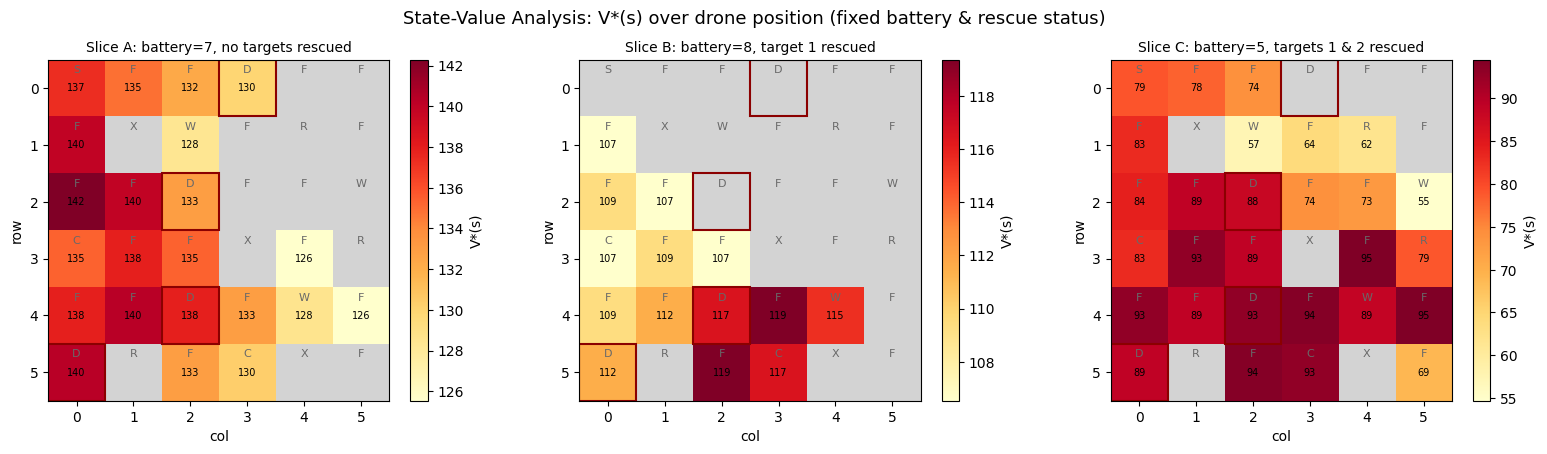

Method: battery and rescue status are fixed; position varies over the 6x6 grid.
Each cell shows max V*(s) over reachable step counts for that configuration.
Gray cells are unreachable for the chosen battery/rescue combination.

Observed patterns:
1. Highest values appear on routes toward unrescued targets (e.g. near R at (1,4) in Slice A).
2. Overall V* drops across slices as battery falls and fewer targets remain (A > B > C).
3. Neighbours of danger zones (D) tend to have lower values because entering D costs -10.
4. Charging stations (C) sit on moderately high-value cells since recharging extends feasible rescue paths.
5. Wind cells (W) are often slightly lower than adjacent safe cells due to 30% stochastic drift.
6. Many R-cell positions are blank after rescue because rescued targets become F and no longer anchor high value.


In [5]:
# State-Value Analysis
def build_value_slice(V, env, battery, rescued):
    """Fix battery and rescue status; for each cell take max V* over reachable step counts."""
    grid = np.full((env.grid_size, env.grid_size), np.nan)
    for r in range(env.grid_size):
        for c in range(env.grid_size):
            vals = [v for (rr, cc, b, rs, _), v in V.items()
                    if rr == r and cc == c and b == battery and rs == rescued]
            if vals:
                grid[r, c] = max(vals)
    return grid


def plot_state_value_analysis(env, results):
    V = results['V']
    slices = [
        {'battery': 7, 'rescued': (0, 0, 0),
         'title': 'Slice A: battery=7, no targets rescued'},
        {'battery': 8, 'rescued': (1, 0, 0),
         'title': 'Slice B: battery=8, target 1 rescued'},
        {'battery': 5, 'rescued': (1, 1, 0),
         'title': 'Slice C: battery=5, targets 1 & 2 rescued'},
    ]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    cmap = plt.cm.YlOrRd.copy()
    cmap.set_bad(color='lightgray')

    for ax, sl in zip(axes, slices):
        value_grid = build_value_slice(V, env, sl['battery'], sl['rescued'])
        im = ax.imshow(value_grid, origin='upper', cmap=cmap)
        ax.set_title(sl['title'], fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.046, label='V*(s)')
        for r in range(env.grid_size):
            for c in range(env.grid_size):
                symbol = env.initial_grid[r, c]
                if env.initial_grid[r, c] == 'D':
                    ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                                 fill=False, edgecolor='darkred', linewidth=1.5))
                if not np.isnan(value_grid[r, c]):
                    ax.text(c, r, f'{value_grid[r, c]:.0f}', ha='center', va='center', fontsize=7)
                ax.text(c, r - 0.32, symbol, ha='center', va='center', fontsize=8, color='dimgray')
        ax.set_xticks(range(env.grid_size))
        ax.set_yticks(range(env.grid_size))
        ax.set_xlabel('col')
        ax.set_ylabel('row')

    fig.suptitle('State-Value Analysis: V*(s) over drone position (fixed battery & rescue status)', fontsize=13)
    plt.tight_layout()
    plt.show()

    print('Method: battery and rescue status are fixed; position varies over the 6x6 grid.')
    print('Each cell shows max V*(s) over reachable step counts for that configuration.')
    print('Gray cells are unreachable for the chosen battery/rescue combination.')
    print()
    print('Observed patterns:')
    print('1. Highest values appear on routes toward unrescued targets (e.g. near R at (1,4) in Slice A).')
    print('2. Overall V* drops across slices as battery falls and fewer targets remain (A > B > C).')
    print('3. Neighbours of danger zones (D) tend to have lower values because entering D costs -10.')
    print('4. Charging stations (C) sit on moderately high-value cells since recharging extends feasible rescue paths.')
    print('5. Wind cells (W) are often slightly lower than adjacent safe cells due to 30% stochastic drift.')
    print('6. Many R-cell positions are blank after rescue because rescued targets become F and no longer anchor high value.')


plot_state_value_analysis(env, results)

## 5. DP Scalability Discussion

### Curse of Dimensionality

Dynamic Programming (tabulated value iteration) stores and updates a value **V(s)** for every reachable state **s**. Performance therefore depends on **|S|**, the size of the state space, and on how many Bellman updates are needed per state.

In our drone rescue problem, a state is:

**s = (row, col, battery, rescued_status, steps)**

Each new variable or larger domain multiplies the number of states. This exponential growth with problem features is the **curse of dimensionality**: a slightly richer model can make exact DP memory and runtime impractical.

For our **6×6** grid, value iteration found **103,763 reachable states** in ~17 seconds. A naive upper bound is:

> 6 × 6 × 11 battery levels × 2³ rescue combinations × 76 steps ≈ **241,000** states

Only ~43% of that bound is reachable, but the scale already shows why DP is sensitive to grid size and mission complexity.

---

### How the State Space Changes

#### 1. Grid becomes 10×10

Position grows from 6×6 = **36** to 10×10 = **100** cells (~**2.8×** on position alone).

With the same battery (11 levels), 3 targets (2³ = 8 rescue combinations), and a similar 75-step horizon, the naive upper bound becomes:

> 100 × 11 × 8 × 76 ≈ **670,000** states

If the step limit scales with grid size (e.g. 125 steps for a larger map), the bound exceeds **1.1 million** states. Memory for V(s) and the transition table grows linearly with |S|, and each value-iteration sweep costs **O(|S| × |A| × branching factor)**. A 10×10 map is still possible on a laptop, but runtime and RAM increase sharply compared with 6×6.

#### 2. More rescue targets are added

Rescue status is a binary flag per target, so **k targets** contribute a factor of **2^k**.

| Targets | Rescue combinations | Multiplier vs 3 targets |
|---------|---------------------|-------------------------|
| 3       | 8                   | 1×                      |
| 5       | 32                  | 4×                      |
| 8       | 256                 | 32×                     |

Adding targets also lengthens typical mission paths, so the useful range of **steps** often increases as well. Combined with a larger grid, |S| can grow by orders of magnitude.

#### 3. Weather becomes dynamic

Currently, wind is a **fixed cell label (W)** with a 30% random action perturbation. The weather is implicit in the map, not part of the state.

If weather is **dynamic**, the environment must track evolving conditions, for example:

- a global weather mode (clear / gusty / storm),
- per-cell wind direction that changes over time,
- or a full weather map updated each step.

Each extra weather variable multiplies |S|. A compact global weather variable with 4 modes adds **×4**. A per-cell weather field over 100 cells with 4 modes each adds up to **4^100** in the worst case—clearly intractable for tabular DP. Even a simplified weather vector (e.g. 10 zones × 4 modes) adds **4^10 ≈ 1 million** weather configurations on top of position, battery, and rescue status.

Dynamic weather also increases the **stochastic branching factor** at each step, making each Bellman backup more expensive.

---

### Is DP Sufficient?

**For this assignment (6×6, 3 targets, static wind): yes.** Exact value iteration is feasible, interpretable, and gives a guaranteed optimal policy for the model.

**For larger or richer real-world settings: generally no.** Tabular DP does not scale well because:

1. **Memory** — must store V(s) [and often transitions] for every reachable state.
2. **Compute** — each iteration scans the full state space; complex dynamics multiply cost per state.
3. **Model enumeration** — transitions must be specified or sampled for all (s, a) pairs; dynamic weather and continuous variables (GPS coordinates, altitude, velocity) blow up or infinite-ize |S|.
4. **Re-planning** — real drones face changing maps, moving victims, and new hazards; recomputing full DP online is too slow.
5. **Partial observability** — real sensors do not give perfect grid coordinates; DP assumes a fully observed state.

---

### How Deep RL Could Help

Deep RL replaces the explicit table **V(s)** with a **neural network V(s; θ)** or **π(a|s; θ)**, enabling generalisation across similar states:

| Approach | Role in drone rescue |
|----------|------------------------|
| **DQN / Deep Q-Network** | Approximate Q*(s, a) over large discrete state spaces |
| **PPO / A2C (policy gradient)** | Learn stochastic policies robust to wind and sensor noise |
| **Distributional RL** | Model risk around danger zones and battery depletion |
| **Model-based RL (Dreamer, MuZero)** | Learn transition models for faster planning without full tabular enumeration |
| **Sim-to-real transfer** | Train in simulation, fine-tune on real flight data |

Function approximation lets the agent **interpolate**: states never visited during training can still receive reasonable values. Experience replay and parallel simulation further improve sample efficiency. These methods trade **optimality guarantees** for **scalability** and adaptability.

---

### Relation to Real-World Autonomous Drone Systems

Real autonomous rescue drones operate in **continuous 3D space** with **LiDAR/camera observations**, **moving targets**, **no-fly zones**, **battery degradation**, **communication dropouts**, and **regulatory constraints**. The true state is high-dimensional and partially observed—far beyond a 6×6 tabular model.

Typical industry practice:

- **Small / structured problems** — DP or mixed-integer planning for discrete routing (e.g. warehouse drones).
- **Large / uncertain missions** — Deep RL plus classical planning: RL for low-level control and obstacle avoidance; A*, RRT, or MILP for coarse waypoint planning.
- **Safety-critical deployment** — policies are validated in simulation, tested with human oversight, and often combined with rule-based fallbacks (geofencing, return-to-home on low battery).

**Conclusion:** DP is an excellent **foundation** for understanding optimal decision-making and verifying small environments (as in this project). For production-scale autonomous rescue, **hybrid architectures**—classical planning + deep RL + robust control—are needed because the curse of dimensionality makes exact tabular DP insufficient, while learned policies can generalise across the vast, dynamic state spaces encountered in the field.
